In [24]:
#Importing necessary libraries
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

#Loading the dataset
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Cleanup the Data
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [56]:
#Filter for Job Title and Country
job_titles = 'Data Scientist'
job_country = 'India'

In [57]:
df_Data_Jobs = df[(df['job_title_short'] == job_titles) & (df['job_country'] == job_country)].copy()

In [58]:
df_Data_Jobs = df_Data_Jobs.dropna(subset = ['salary_year_avg'])

df_Data_Jobs_exploded = df_Data_Jobs.explode('job_skills')

df_Data_Jobs_exploded[['salary_year_avg', 'job_skills']].head(5)

df_Data_Jobs_skills = df_Data_Jobs_exploded.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values(by = 'count', ascending = False).head(10)

df_Data_Jobs_skills = df_Data_Jobs_skills.rename(columns = {'count': 'skill_count', 'median': 'median_salary'})

Data_Jobs_count = len(df_Data_Jobs)

df_Data_Jobs_skills['skill_percent']  = df_Data_Jobs_skills['skill_count'] / Data_Jobs_count * 100



C:\Users\sujay\AppData\Local\Temp\ipykernel_25936\3908228669.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  texts.append(plt.text(df_Data_Jobs_skills['skill_percent'][i], df_Data_Jobs_skills['median_salary'][i], txt))


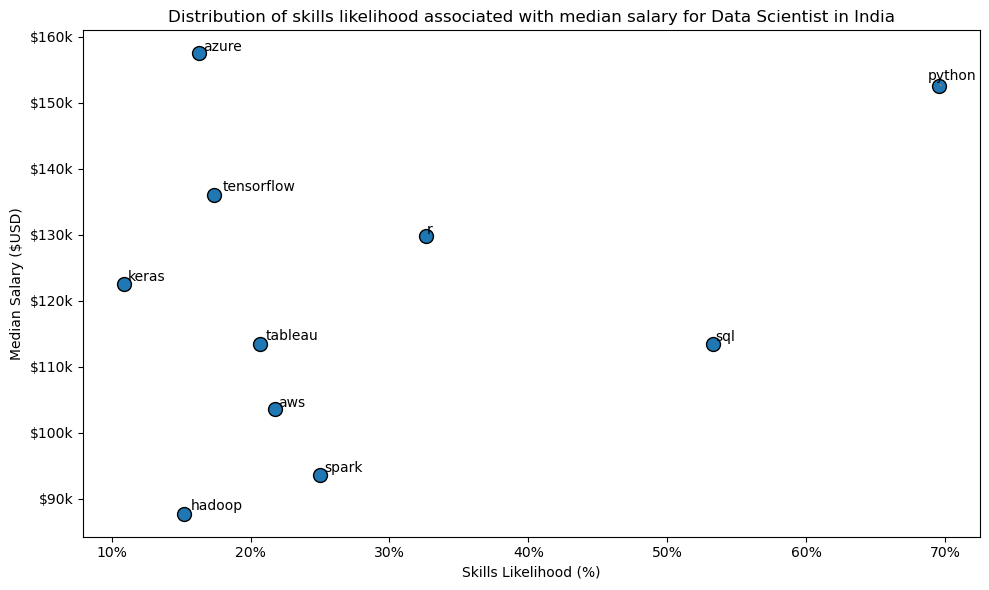

In [63]:
import matplotlib.pyplot as plt
import ast
from adjustText import adjust_text

df_Data_Jobs_skills.plot(kind = 'scatter', x = 'skill_percent', y = 'median_salary', edgecolor = 'black', s = 100, figsize = (10, 6))

texts = []

for i, txt in enumerate(df_Data_Jobs_skills.index):
    texts.append(plt.text(df_Data_Jobs_skills['skill_percent'][i], df_Data_Jobs_skills['median_salary'][i], txt))

adjust_text(texts, arrowprops = dict(arrowstyle = '->', color = 'gray'))

plt.title(f'Distribution of skills likelihood associated with median salary for {job_titles} in {job_country}')
plt.xlabel('Skills Likelihood (%)')
plt.ylabel('Median Salary ($USD)')

ticks_x = plt.FuncFormatter(lambda x, pos: f'{int(x)}%')
plt.gca().xaxis.set_major_formatter(ticks_x)

ticks_y = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}k')
plt.gca().yaxis.set_major_formatter(ticks_y)

plt.tight_layout()
plt.show()